In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# Data

In [42]:
index = [
    "qwen2.5:14b",
    "deepseek-r1:14b",
    "gemma3:27b",
    "granite-code:20b",
    "llama3.1:8b",
    "phi4:14b",
    "codestral:22b",
    "gpt-oss:20b"
]

benchmark_scores = {
    "qwen2.5:14b": [0.1110, 0.1431, 0.0992, 0.1389, 0.1022, 0.0920, 0.1489, 0.1720],
    "deepseek-r1:14b": [0.1488, 0.1573, 0.1541, 0.1851, 0.1461, 0.1434, 0.1434, 0.1968],
    "gemma3:27b": [0.1492, 0.1679, 0.1488, 0.1894, 0.1389, 0.1220, 0.1496, 0.1434],
    "granite-code:20b": [0.1358, 0.1925, 0.1371, 0.1221, 0.1125, 0.1298, 0.1463, 0.1612],
    "llama3.1:8b": [0.3224, 0.3575, 0.3052, 0.3374, 0.2756, 0.2549, 0.3515, 0.2877],
    "phi4:14b": [0.1922, 0.2081, 0.2053, 0.2819, 0.1056, 0.1400, 0.1567, 0.2285],
    "codestral:22b": [0.0499, 0.0451, 0.0359, 0.0372, 0.0125, 0.0403, 0.0255, 0.0627],
    "gpt-oss:20b": [0.3736, 0.3797, 0.3955, 0.3917, 0.3463, 0.3809, 0.3553, 0.4509]
}

yamllint_scores = {
    "qwen2.5:14b": [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0009, 1.0000],
    "deepseek-r1:14b": [1.1314, 1.1127, 1.0932, 1.1284, 1.0980, 1.1041, 1.1004, 1.1128],
    "gemma3:27b": [1.1432, 1.1398, 1.1534, 1.1386, 1.1519, 1.0987, 1.1384, 1.1220],
    "granite-code:20b": [1.2037, 1.2401, 1.2077, 1.2050, 1.2302, 1.2002, 1.1860, 1.1995],
    "llama3.1:8b": [1.0609, 1.0561, 1.0702, 1.0443, 1.0628, 1.0750, 1.0593, 1.0668],
    "phi4:14b": [1.1291, 1.1449, 1.1466, 1.1908, 1.1248, 1.0851, 1.1250, 1.1478],
    "codestral:22b": [1.0077, 1.0116, 1.0038, 1.0056, 1.0116, 1.0098, 1.0105, 1.0041],
    "gpt-oss:20b": [1.2340, 1.2367, 1.2572, 1.2701, 1.1812, 1.1782, 1.2272, 1.2500]
}

ansiblelint_scores = {
    "qwen2.5:14b": [1.0000, 1.0309, 1.0256, 1.0263, 1.0449, 1.0656, 1.0435, 1.1667],
    "deepseek-r1:14b": [1.0146, 1.0510, 1.0254, 1.0122, 1.0076, 1.0278, 1.0928, 1.1359],
    "gemma3:27b": [1.0000, 1.0086, 1.0080, 1.0400, 1.0517, 1.0500, 1.0531, 1.1222],
    "granite-code:20b": [1.0000, 1.0152, 1.0063, 1.0058, 1.0053, 1.0256, 1.0370, 1.0719],
    "llama3.1:8b": [1.5250, 1.4667, 1.4756, 1.4038, 1.4706, 1.3929, 1.4824, 1.5200],
    "phi4:14b": [1.0278, 1.0536, 1.0336, 1.0621, 1.0238, 1.0769, 1.0860, 1.2258],
    "codestral:22b": [1.2353, 1.2105, 1.1579, 1.2105, 1.0909, 1.2143, 1.0588, 1.5294],
    "gpt-oss:20b": [1.0263, 1.0149, 1.0145, 1.0199, 1.0077, 1.0565, 1.0179, 1.2026]
}

def to_minutes(hm):
    h, m = hm.split(":")
    return int(h) * 60 + int(m)

duration_runs = {
    "qwen2.5:14b": [to_minutes(x) for x in ["1:42", "1:56", "1:49", "1:36", "1:45", "1:56", "2:10", "2:19"]],
    "deepseek-r1:14b": [to_minutes(x) for x in ["3:59", "4:07", "2:37", "4:06", "4:39", "4:18", "4:16", "4:11"]],
    "gemma3:27b": [to_minutes(x) for x in ["4:42", "4:02", "4:50", "4:12", "4:26", "4:54", "4:50", "5:19"]],
    "granite-code:20b": [to_minutes(x) for x in ["2:04", "2:11", "2:05", "1:30", "1:39", "2:00", "1:55", "2:04"]],
    "llama3.1:8b": [to_minutes(x) for x in ["1:43", "2:12", "2:22", "1:53", "1:59", "1:43", "2:07", "1:28"]],
    "phi4:14b": [to_minutes(x) for x in ["2:03", "1:49", "2:08", "2:11", "1:37", "1:40", "1:43", "2:11"]],
    "codestral:22b": [to_minutes(x) for x in ["1:49", "2:15", "2:00", "1:31", "1:51", "2:00", "2:00", "2:43"]],
    "gpt-oss:20b": [to_minutes(x) for x in ["4:17", "4:18", "4:37", "3:17", "6:43", "5:34", "4:47", "4:55"]]
}

df_file_information = pd.read_csv("overall_report.csv", delimiter=";")
df_benchmark_scores = pd.DataFrame(benchmark_scores, index=index)
df_yamllint_scores = pd.DataFrame(yamllint_scores, index=index)
df_ansiblelint_scores = pd.DataFrame(ansiblelint_scores, index=index)
df_duration_runs = pd.DataFrame(duration_runs, index=index)



# Analysis of Benchmark-Scores

In [19]:
print(df_benchmark_scores.describe())

       qwen2.5:14b  deepseek-r1:14b  gemma3:27b  granite-code:20b  \
count     8.000000         8.000000    8.000000          8.000000   
mean      0.125912         0.159375    0.151150          0.142163   
std       0.028698         0.020329    0.020054          0.025113   
min       0.092000         0.143400    0.122000          0.112500   
25%       0.101450         0.145425    0.142275          0.127875   
50%       0.124950         0.151450    0.149000          0.136450   
75%       0.144550         0.164250    0.154175          0.150025   
max       0.172000         0.196800    0.189400          0.192500   

       llama3.1:8b  phi4:14b  codestral:22b  gpt-oss:20b  
count     8.000000  8.000000       8.000000     8.000000  
mean      0.311525  0.189787       0.038638     0.384238  
std       0.037041  0.055067       0.015193     0.031731  
min       0.254900  0.105600       0.012500     0.346300  
25%       0.284675  0.152525       0.033300     0.369025  
50%       0.313800  0.19

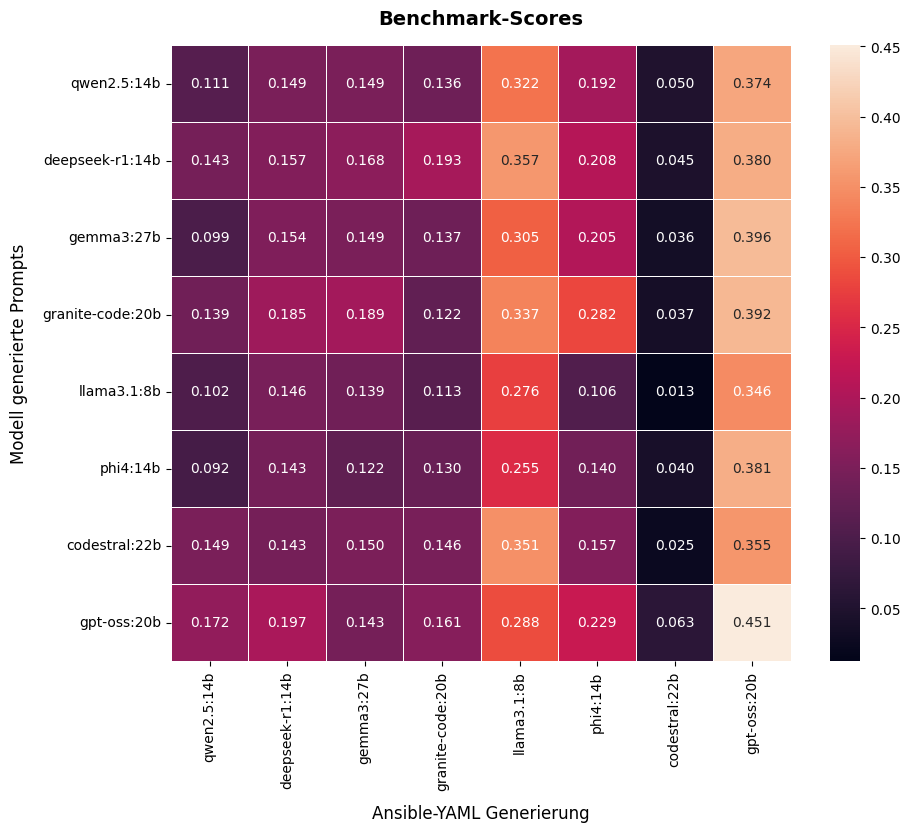

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_benchmark_scores, annot=True, fmt=".3f", linewidths=0.5 )
plt.title("Benchmark-Scores", fontsize=14, pad=15, weight='bold')
plt.xlabel("Ansible-YAML Generierung", fontsize=12, labelpad=10)
plt.ylabel("Modell generierte Prompts", fontsize=12, labelpad=10)
plt.show()

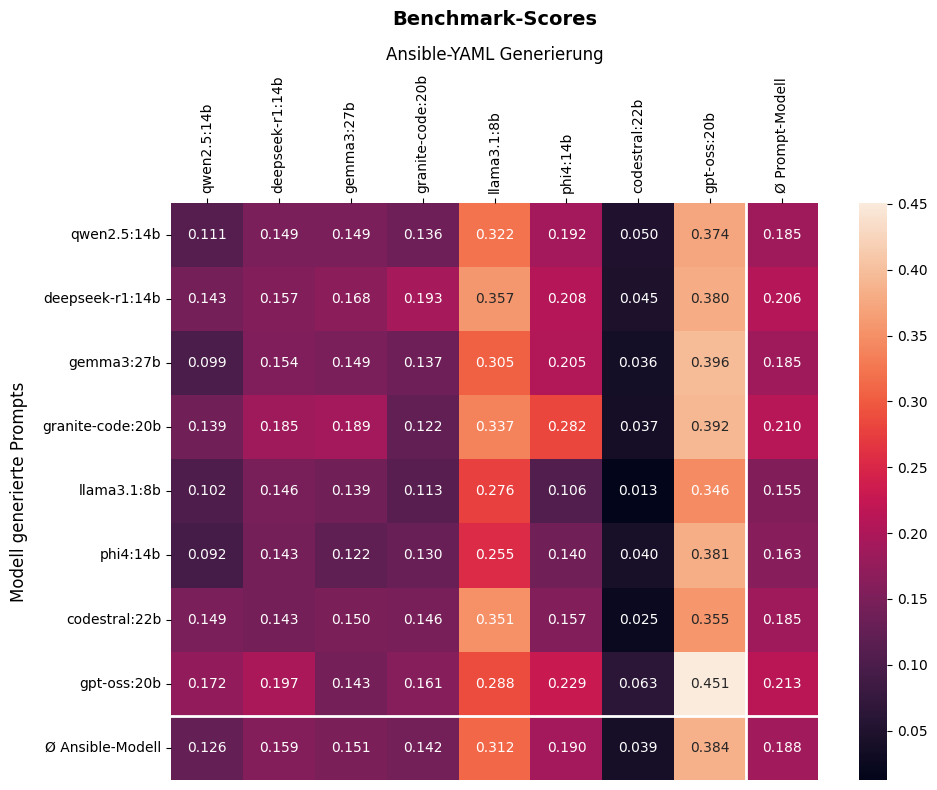

In [ ]:
df_benchmark_scores_extended = df_benchmark_scores.copy()
df_benchmark_scores_extended["Ø Prompt-Modell"] = df_benchmark_scores_extended.mean(axis=1)
df_benchmark_scores_extended.loc["Ø Ansible-Modell"] = df_benchmark_scores_extended.mean(axis=0)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    df_benchmark_scores_extended,
    annot=True,
    fmt=".3f",
    cbar=True,
)

ax.set_title("Benchmark-Scores", fontsize=14, pad=15, weight='bold')
ax.set_xlabel("Modell Generierung Ansible-YAML", fontsize=12, labelpad=10)
ax.set_ylabel("Modell Generierung Prompts", fontsize=12, labelpad=10)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

plt.xticks(rotation=90)
n = len(df_benchmark_scores.columns)  
ax.axhline(n, color='white', lw=2)    
ax.axvline(n, color='white', lw=2)   

plt.tight_layout()
plt.show()

# Analysis of Ansible-Lint-Scores

In [35]:
print(df_ansiblelint_scores.describe())

       qwen2.5:14b  deepseek-r1:14b  gemma3:27b  granite-code:20b  \
count     8.000000         8.000000    8.000000          8.000000   
mean      1.050438         1.045913    1.041700          1.020888   
std       0.050640         0.045757    0.039192          0.024012   
min       1.000000         1.007600    1.000000          1.000000   
25%       1.026125         1.014000    1.008450          1.005675   
50%       1.037200         1.026600    1.045000          1.010750   
75%       1.050075         1.061450    1.052050          1.028450   
max       1.166700         1.135900    1.122200          1.071900   

       llama3.1:8b  phi4:14b  codestral:22b  gpt-oss:20b  
count     8.000000  8.000000       8.000000     8.000000  
mean      1.467125  1.073700       1.213450     1.045037  
std       0.047782  0.065508       0.142599     0.065369  
min       1.392900  1.023800       1.058800     1.007700  
25%       1.450975  1.032150       1.141150     1.014800  
50%       1.473100  1.05

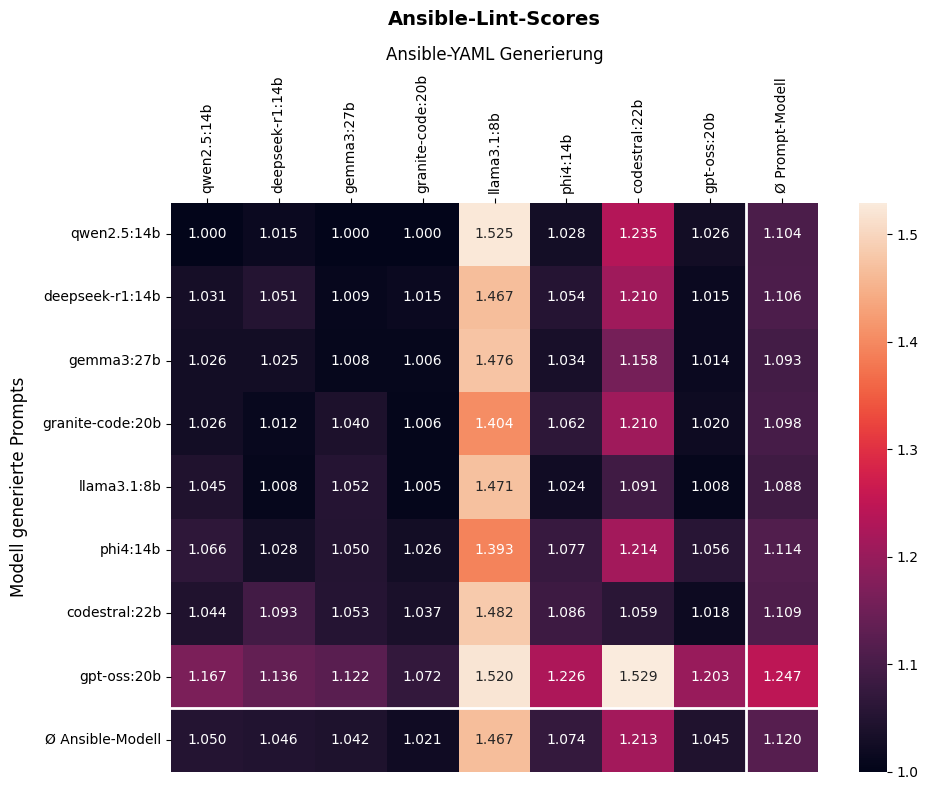

In [ ]:
df_ansiblelint_scores_extended = df_ansiblelint_scores.copy()
df_ansiblelint_scores_extended["Ø Prompt-Modell"] = df_ansiblelint_scores_extended.mean(axis=1)
df_ansiblelint_scores_extended.loc["Ø Ansible-Modell"] = df_ansiblelint_scores_extended.mean(axis=0)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    df_ansiblelint_scores_extended,
    annot=True,
    fmt=".3f",
    cbar=True,
)

ax.set_title("Ansible-Lint-Scores", fontsize=14, pad=15, weight='bold')
ax.set_xlabel("Modell Generierung Ansible-YAML", fontsize=12, labelpad=10)
ax.set_ylabel("Modell Generierung Prompts", fontsize=12, labelpad=10)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

plt.xticks(rotation=90)
n = len(df_benchmark_scores.columns)  
ax.axhline(n, color='white', lw=2)    
ax.axvline(n, color='white', lw=2)   

plt.tight_layout()
plt.show()

# Analysis of YAMLLint-Scores

In [37]:
print(df_ansiblelint_scores.describe())

       qwen2.5:14b  deepseek-r1:14b  gemma3:27b  granite-code:20b  \
count     8.000000         8.000000    8.000000          8.000000   
mean      1.050438         1.045913    1.041700          1.020888   
std       0.050640         0.045757    0.039192          0.024012   
min       1.000000         1.007600    1.000000          1.000000   
25%       1.026125         1.014000    1.008450          1.005675   
50%       1.037200         1.026600    1.045000          1.010750   
75%       1.050075         1.061450    1.052050          1.028450   
max       1.166700         1.135900    1.122200          1.071900   

       llama3.1:8b  phi4:14b  codestral:22b  gpt-oss:20b  
count     8.000000  8.000000       8.000000     8.000000  
mean      1.467125  1.073700       1.213450     1.045037  
std       0.047782  0.065508       0.142599     0.065369  
min       1.392900  1.023800       1.058800     1.007700  
25%       1.450975  1.032150       1.141150     1.014800  
50%       1.473100  1.05

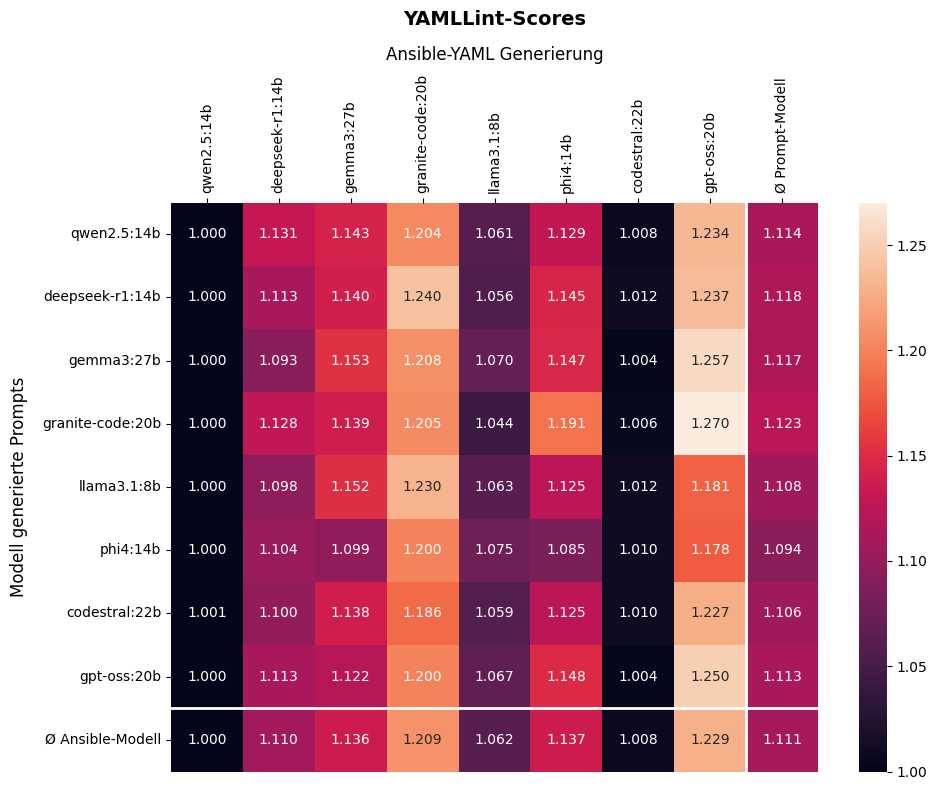

In [ ]:
df_yamllint_scores_extended = df_yamllint_scores.copy()
df_yamllint_scores_extended["Ø Prompt-Modell"] = df_yamllint_scores_extended.mean(axis=1)
df_yamllint_scores_extended.loc["Ø Ansible-Modell"] = df_yamllint_scores_extended.mean(axis=0)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    df_yamllint_scores_extended,
    annot=True,
    fmt=".3f",
    cbar=True,
)

ax.set_title("YAMLLint-Scores", fontsize=14, pad=15, weight='bold')
ax.set_xlabel("Modell Generierung Ansible-YAML", fontsize=12, labelpad=10)
ax.set_ylabel("Modell Generierung Prompts", fontsize=12, labelpad=10)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

plt.xticks(rotation=90)
n = len(df_benchmark_scores.columns)  
ax.axhline(n, color='white', lw=2)    
ax.axvline(n, color='white', lw=2)   

plt.tight_layout()
plt.show()

# Analysis of File-Information 

In [65]:
# Neue Spalten hinzufügen
df_file_information["Yamllint passed"] = (
    df_file_information["Ansiblelint failed"] + 
    df_file_information["Molecule failed"] + 
    df_file_information["Molecule passed"]
)

df_file_information["Ansiblelint passed"] = (
    df_file_information["Molecule failed"] + 
    df_file_information["Molecule passed"]
)

df_file_information.head()


,Datei,Yamllint failed,Ansiblelint failed,Molecule failed,Molecule passed,Total runs,File size (chars),Yamllint passed,Ansiblelint passed
0,ansible-role-cadvisor/tasks/main.yml,41,5,17,1,64,1696,23,18
1,ansible-role-pip/tasks/main.yml,29,5,26,4,64,880,35,30
2,ansible-role-epel-buluma/tasks/main.yml,39,4,18,3,64,756,25,21
3,ansible-role-mysql/tasks/main.yml,38,9,17,0,64,2615,26,17
4,ansible-role-bootstrap-buluma/tasks/main.yml,36,13,15,0,64,2122,28,15


In [46]:
print(df_file_information.describe())

       Yamllint failed  Ansiblelint failed  Molecule failed  Molecule passed  \
count       100.000000          100.000000       100.000000       100.000000   
mean         32.980000            5.650000        18.420000         6.950000   
std          13.913862            3.688297        11.110265        10.682162   
min           6.000000            0.000000         0.000000         0.000000   
25%          21.500000            3.000000        11.000000         0.000000   
50%          35.500000            5.000000        17.000000         3.000000   
75%          43.000000            8.000000        27.250000        10.000000   
max          61.000000           19.000000        41.000000        53.000000   

       Total runs  File size (chars)  
count       100.0         100.000000  
mean         64.0        1661.370000  
std           0.0        1807.581383  
min          64.0         115.000000  
25%          64.0         570.500000  
50%          64.0        1049.000000  
75%   

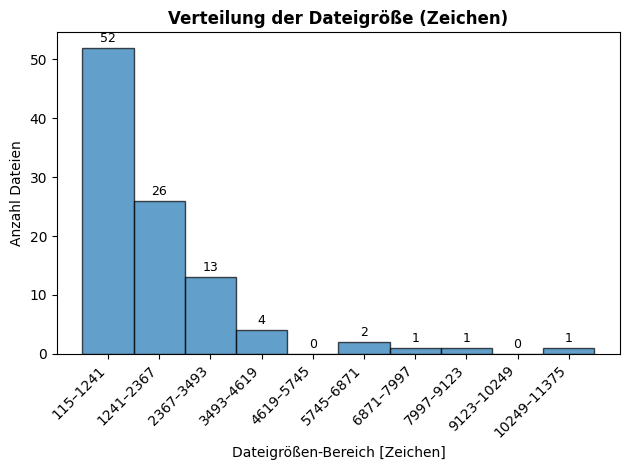

In [ ]:
data = df_file_information["File size (chars)"]
counts, bins, patches = plt.hist(data, bins=10, edgecolor='black', alpha=0.7)
bin_labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
bin_centers = 0.5 * (bins[1:] + bins[:-1])
plt.xticks(bin_centers, bin_labels, rotation=45, ha='right')
for count, x in zip(counts, bin_centers):
    plt.text(
        x, count + 0.5,
        f"{int(count)}",
        ha='center', va='bottom', fontsize=9
    )
plt.title("Verteilung der Dateigröße (Zeichen)", weight='bold')
plt.xlabel("Dateigrößen-Bereich [Zeichen]")
plt.ylabel("Anzahl Dateien")

plt.tight_layout()
plt.show()


/tmp/ipykernel_2732674/1615384237.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=corrs.values, y=corrs.index, palette="coolwarm", orient="h")


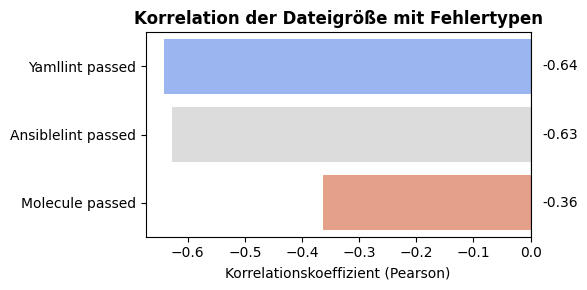

Yamllint passed      -0.641591
Ansiblelint passed   -0.627754
Molecule passed      -0.363271
Name: File size (chars), dtype: float64


In [68]:
corrs = df_file_information[[ 
    "File size (chars)",
    "Yamllint passed",
    "Ansiblelint passed",
    "Molecule passed"
]].corr()["File size (chars)"].drop("File size (chars)")

corrs = corrs.sort_values(ascending=True)

plt.figure(figsize=(6, 3))
ax = sns.barplot(x=corrs.values, y=corrs.index, palette="coolwarm", orient="h")

plt.axvline(0, color='black', linewidth=0.8)
plt.title("Korrelation der Dateigröße mit Fehlertypen", weight='bold')
plt.xlabel("Korrelationskoeffizient (Pearson)")
plt.ylabel("")

for i, v in enumerate(corrs.values):
    if v >= 0:
        ax.text(-0.02, i, f"{v:.2f}", color='black', va='center', ha='right')
    else:
        ax.text(0.02, i, f"{v:.2f}", color='black', va='center', ha='left')

plt.tight_layout()
plt.show()

print(corrs)

/tmp/ipykernel_2732674/826789978.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_success.index, y=rel_success.values, palette="viridis")


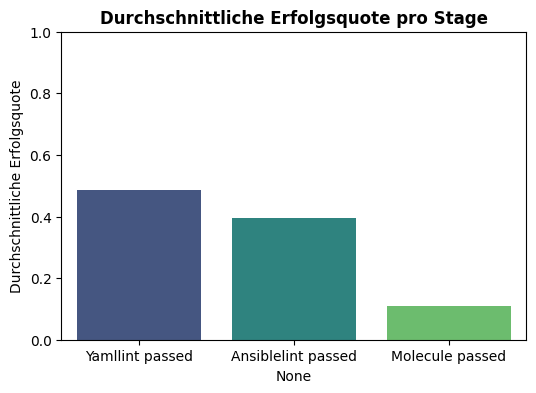

In [69]:
stages_passed = ["Yamllint passed", "Ansiblelint passed", "Molecule passed"]
stages_failed = ["Yamllint failed", "Ansiblelint failed", "Molecule failed"]

# Balkendiagramm: relative Erfolgsquote
rel_success = df_file_information[stages_passed].div(df_file_information["Total runs"], axis=0).mean()
plt.figure(figsize=(6,4))
sns.barplot(x=rel_success.index, y=rel_success.values, palette="viridis")
plt.ylabel("Durchschnittliche Erfolgsquote")
plt.title("Durchschnittliche Erfolgsquote pro Stage", weight='bold')
plt.ylim(0,1)
plt.show()

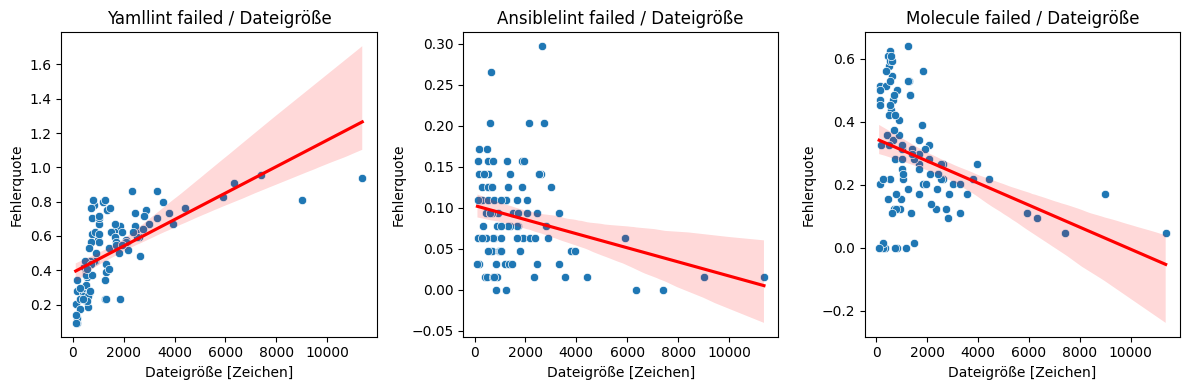

In [70]:
plt.figure(figsize=(12,4))
for i, stage in enumerate(stages_failed,1):
    plt.subplot(1,3,i)
    sns.scatterplot(
        x=df_file_information["File size (chars)"], 
        y=df_file_information[stage]/df_file_information["Total runs"]
    )
    sns.regplot(
        x=df_file_information["File size (chars)"], 
        y=df_file_information[stage]/df_file_information["Total runs"], 
        scatter=False, color='red'
    )
    plt.title(stage + " / Dateigröße")
    plt.xlabel("Dateigröße [Zeichen]")
    plt.ylabel("Fehlerquote")
plt.tight_layout()
plt.show()

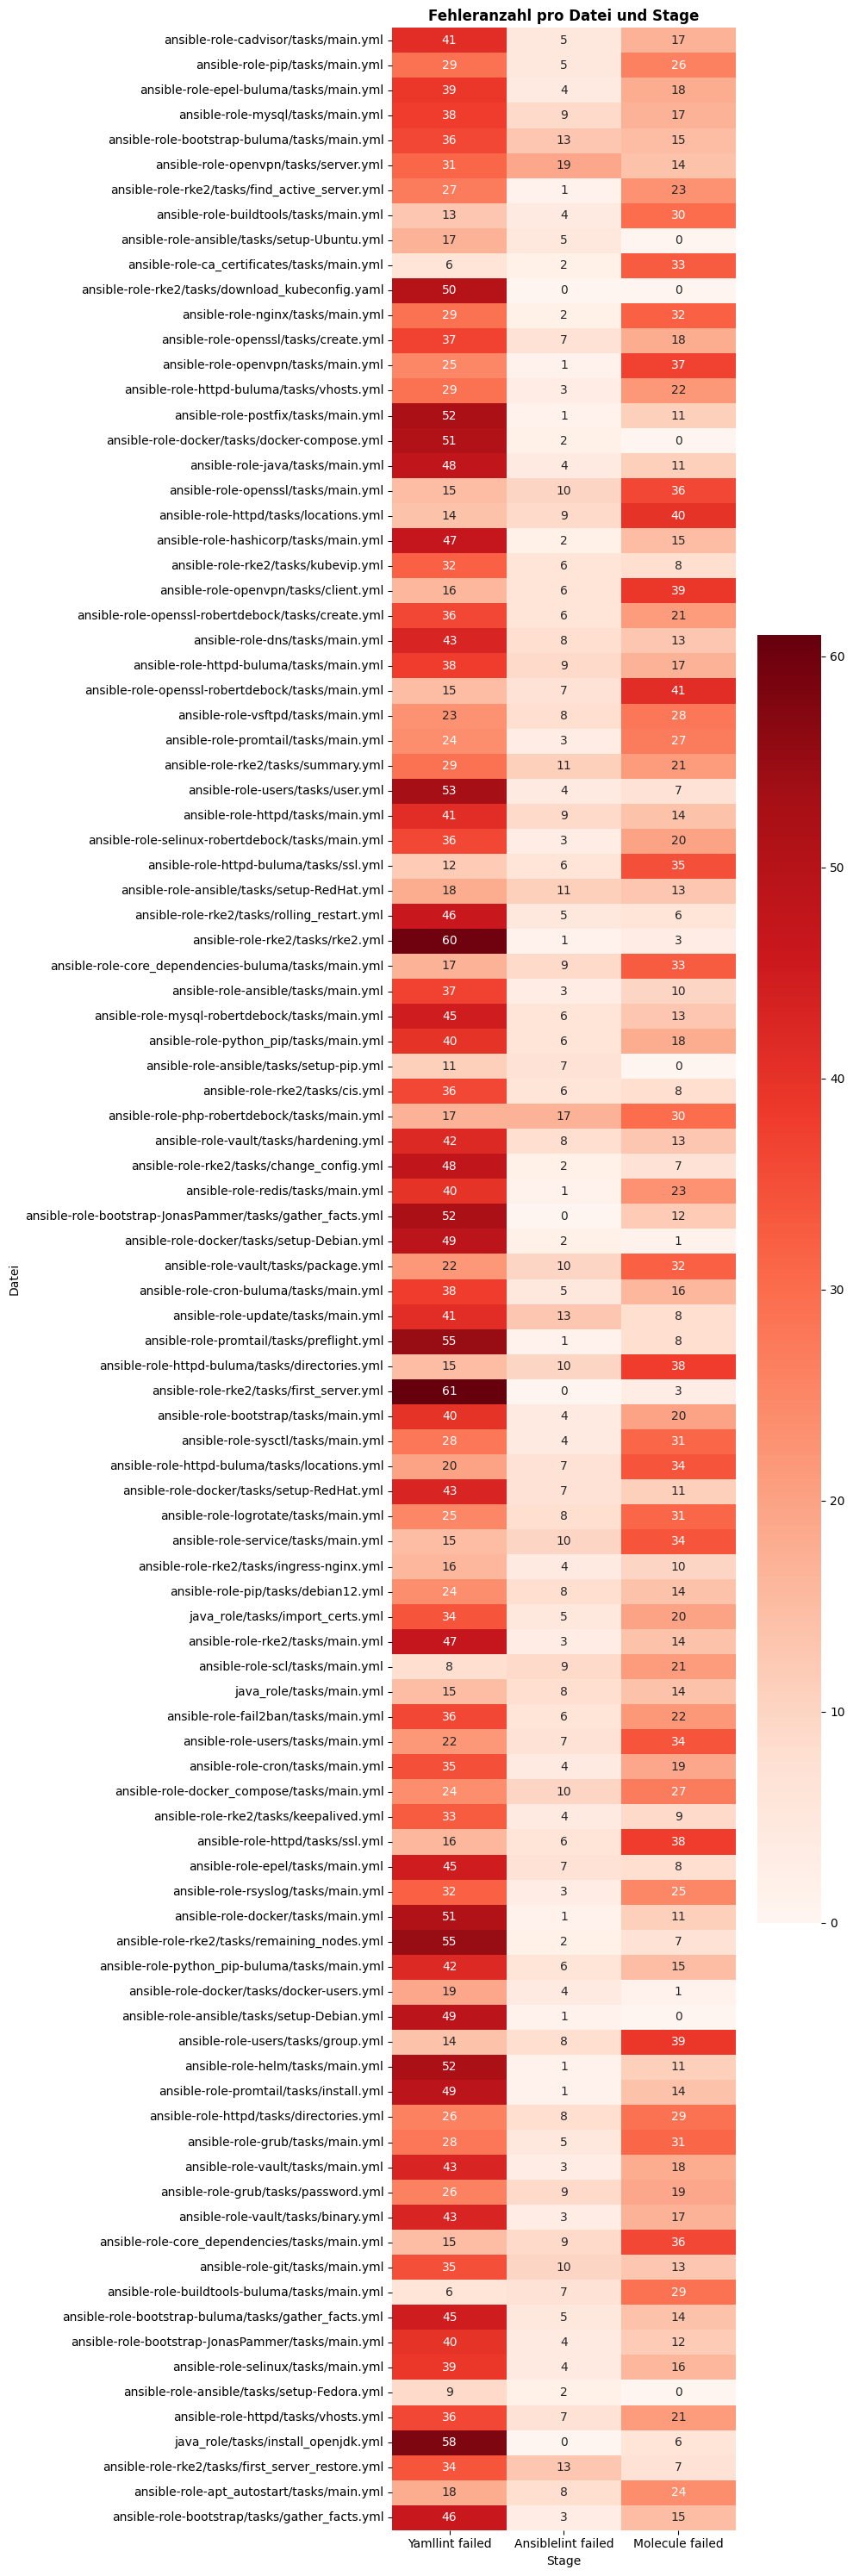

In [73]:
heat_data = df_file_information[stages_failed]
plt.figure(figsize=(10,30))
sns.heatmap(heat_data, annot=True, fmt="d", cmap="Reds", yticklabels=df_file_information["Datei"])
plt.title("Fehleranzahl pro Datei und Stage", weight='bold')
plt.ylabel("Datei")
plt.xlabel("Stage")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2732674/84154774.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_ratios = df_file_information.groupby(bins)[stages_failed].sum() / df_file_information.groupby(bins).size().values.reshape(-1,1)
/tmp/ipykernel_2732674/84154774.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_ratios = df_file_information.groupby(bins)[stages_failed].sum() / df_file_information.groupby(bins).size().values.reshape(-1,1)


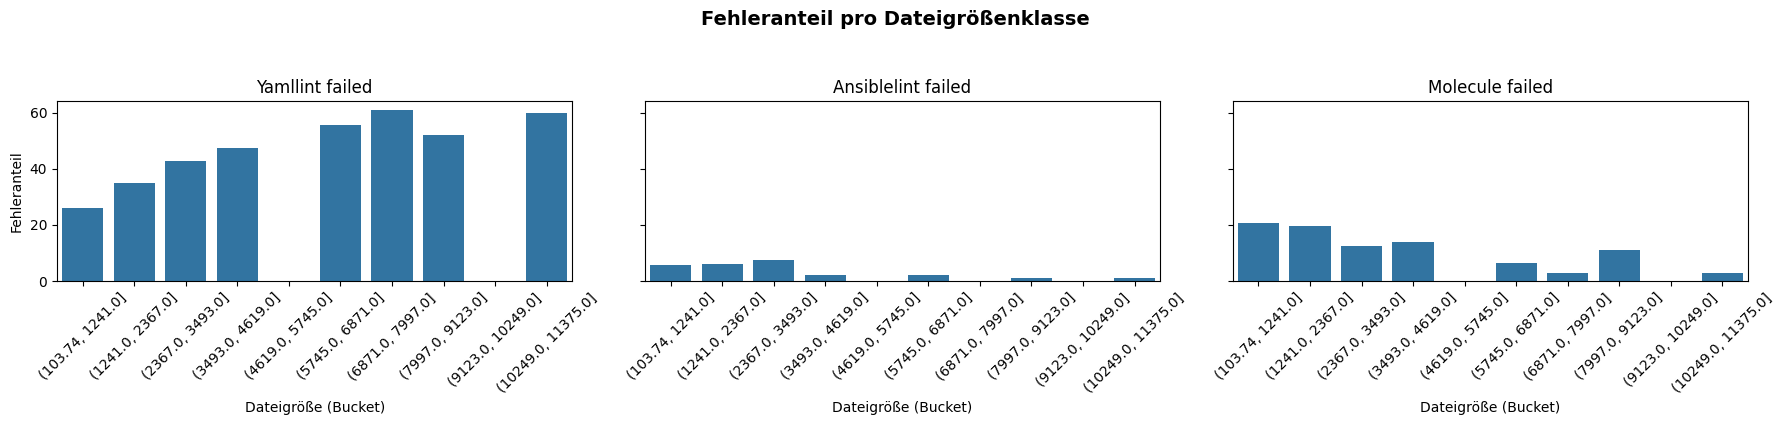

In [74]:
bins = pd.cut(df_file_information["File size (chars)"], bins=10)
failure_ratios = df_file_information.groupby(bins)[stages_failed].sum() / df_file_information.groupby(bins).size().values.reshape(-1,1)

fig, axes = plt.subplots(1,3, figsize=(18,4), sharey=True)
for i, stage in enumerate(stages_failed):
    sns.barplot(
        x=failure_ratios.index.astype(str), 
        y=failure_ratios[stage], 
        ax=axes[i], 
        color="tab:blue"
    )
    axes[i].set_title(stage)
    axes[i].set_xlabel("Dateigröße (Bucket)")
    if i==0:
        axes[i].set_ylabel("Fehleranteil")
    axes[i].tick_params(axis="x", rotation=45)
plt.suptitle("Fehleranteil pro Dateigrößenklasse", fontsize=14, weight='bold', y=1.05)
plt.tight_layout()
plt.show()